# Baseline Models — Random Forest & ANN (SoCrel)

Este notebook implementa os modelos baseline (Random Forest e ANN) para estimação de SoC relativo (SoCrel),
seguindo o protocolo de validação definido no projeto.

- Dataset: LG 18650HG2
- Split: por `file_id` (evita leakage)
- Métricas: MAE, RMSE, R²
- Referência de dataset: Dataset_LG18650HG2_ProjetoBMS (v2.3)


# ============================================================
# CÉLULA 1 
# ============================================================
"""
# Baseline Models — Random Forest & ANN (SoCrel)

Este notebook treina modelos baseline (Random Forest e ANN/MLP) para estimação de SoC relativo (SoCrel).

**Importante**
- Este notebook **não** refaz o carregamento/preprocessamento dos CSV brutos.
- O dataset é carregado a partir de um ficheiro **df_prepared.pkl** adicionado como **Input** no Kaggle.
- Split é feito por **file_id** (evita leakage).

Métricas: MAE, RMSE, R²  
Gráficos: parity plot + erro vs SoCrel  
"""


In [1]:
# ============================================================
# CÉLULA 2 — Diagnóstico completo + carregar df_prepared.pkl
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

print("=== DIAGNÓSTICO DE INPUTS KAGGLE ===")

# 1) Listar inputs montados
inputs = [p for p in Path("/kaggle/input").iterdir() if p.is_dir()]
print("Inputs montados em /kaggle/input:")
for p in inputs:
    print(" -", p.name)

if not inputs:
    raise RuntimeError(
        "Nenhum Input montado em /kaggle/input.\n"
        "Vai a Data → Add Dataset e ativa o dataset correto."
    )

# 2) Procurar df_prepared.pkl em todos os inputs
candidates = list(Path("/kaggle/input").rglob("df_prepared.pkl"))
print("\nCandidatos df_prepared.pkl encontrados:")
for c in candidates:
    print(" -", c)

if len(candidates) == 0:
    raise FileNotFoundError(
        "df_prepared.pkl não encontrado em nenhum Input.\n"
        "Confirma que o dataset de preprocessing foi adicionado."
    )

if len(candidates) > 1:
    raise RuntimeError(
        "Encontrados vários df_prepared.pkl.\n"
        "Remove Inputs duplicados ou define manualmente o caminho."
    )

p = candidates[0]
print("\n✔ df_prepared.pkl selecionado:")
print(" ", p)

# 3) Carregar dataset
df = pd.read_pickle(p)
print("\n✔ Dataset carregado com sucesso.")
print("Shape:", df.shape)

# 4) Verificação de colunas-chave
required_cols = [
    "file_id", "temperature_folder", "soc_rel",
    "time_s", "voltage", "current", "temperature"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(
        f"Colunas essenciais em falta: {missing}\n"
        f"Colunas disponíveis: {list(df.columns)}"
    )

print("\n✔ Colunas essenciais presentes.")

# 5) Distribuição global por temperatura
print("\n=== DISTRIBUIÇÃO POR TEMPERATURA ===")
print(df["temperature_folder"].value_counts())

# 6) Número de ficheiros por temperatura
print("\n=== Nº DE FICHEIROS POR TEMPERATURA ===")
print(df.groupby("temperature_folder")["file_id"].nunique())

# 7) Listagem explícita (amostra) de file_id por temperatura
print("\n=== AMOSTRA DE FILE_ID POR TEMPERATURA ===")
for temp, g in df.groupby("temperature_folder"):
    files = sorted(g["file_id"].unique())
    print(f"\n{temp} — {len(files)} ficheiros")
    print("  exemplos:", files[:10])

# 8) Verificar intervalos de SoC_rel por temperatura
print("\n=== INTERVALO SoC_rel POR TEMPERATURA ===")
soc_stats = (
    df.groupby("temperature_folder")["soc_rel"]
      .agg(["min", "max", "mean"])
)
print(soc_stats)

# 9) Amostra verdadeiramente aleatória (visual)
print("\n=== AMOSTRA ALEATÓRIA DO DATASET ===")
df.sample(5, random_state=42)


=== DIAGNÓSTICO DE INPUTS KAGGLE ===
Inputs montados em /kaggle/input:
 - lg-18650hg2-liion-battery-data
 - dhakal-full

Candidatos df_prepared.pkl encontrados:
 - /kaggle/input/dhakal-full/df_prepared.pkl

✔ df_prepared.pkl selecionado:
  /kaggle/input/dhakal-full/df_prepared.pkl

✔ Dataset carregado com sucesso.
Shape: (4954914, 20)

✔ Colunas essenciais presentes.

=== DISTRIBUIÇÃO POR TEMPERATURA ===
temperature_folder
25degC     1045477
10degC      925530
0degC       850622
n10degC     829826
40degC      692629
n20degC     610830
Name: count, dtype: int64

=== Nº DE FICHEIROS POR TEMPERATURA ===
temperature_folder
0degC      32
10degC     32
25degC     36
40degC     35
n10degC    38
n20degC    35
Name: file_id, dtype: int64

=== AMOSTRA DE FILE_ID POR TEMPERATURA ===

0degC — 32 ficheiros
  exemplos: ['585_C20DisCh', '585_Dis_0p5C', '585_Dis_2C', '585_HPPC', '589_Cap_1C', '589_Charge1', '589_Charge2', '589_Charge3', '589_Charge4', '589_Charge5']

10degC — 32 ficheiros
  exemplos: 

,time_stamp,step,status,prog_time,step_time,cycle,cycle_level,procedure,voltage,current,temperature,capacity,whaccu,cnt,unnamed_14,file_id,temperature_folder,test_type,time_s,soc_rel
4038756,2018-12-16 05:13:57,41.0,TABLE,11:50:09.226,00:21:07.931,1.0,1.0,LG_HG2_CyclesB,3.65890,-3.51443,-8.833320,-0.46203,-1.67823,3.00000,NaN,602_Mixed5,n10degC,Mixed,1266.0,0.218070
4728521,2018-12-26 00:47:53,35.0,TABLE,10:40:59.096,00:22:19.158,1.0,1.0,LG_HG2_CyclesB,3.88916,-0.08939,-19.244011,-0.36908,-1.28095,3.00000,NaN,611_Mixed4,n20degC,Mixed,1338.0,0.240296
1882815,2018-11-14 06:31:56,62.0,PAU,37:10:04.636,00:00:00.703,0.0,0.0,LG_HG2_CyclesA,3.07445,0.00000,11.567440,-2.47958,-8.72294,8.0,NaN,567_Mixed2,10degC,Mixed,7176.0,1.000000
666550,2018-10-30 14:00:33,30.0,TABLE,12:05:53.884,02:03:59.605,1.0,1.0,LG_HG2_CyclesB,3.23751,-0.12004,24.817410,-2.54004,-9.08986,3.0,NaN,552_Mixed4,25degC,Mixed,7438.0,0.992805
371369,2018-10-28 19:15:21,25.0,TABLE,08:12:16.896,01:31:23.036,1.0,1.0,LG_HG2_CyclesA,3.91663,-0.10216,23.870991,-0.83853,-3.29819,3.00000,NaN,551_UDDS,25degC,DriveCycle,5481.0,0.323730


In [2]:
# ============================================================
# CÉLULA 3 (Code) — Deteção robusta de colunas essenciais + checks
# ============================================================

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

col_file = pick_col(df, ["file_id", "file", "id"])
col_time = pick_col(df, ["time_s", "time", "Time", "Time Stamp", "timestamp"])
col_v    = pick_col(df, ["Voltage", "voltage", "V"])
col_i    = pick_col(df, ["Current", "current", "I"])
col_t    = pick_col(df, ["Temperature", "temperature", "Temp", "T"])
col_soc  = pick_col(df, ["SoCrel", "soc_rel", "SoC_rel", "SoC", "soc"])

required = {
    "file_id": col_file,
    "time": col_time,
    "voltage": col_v,
    "current": col_i,
    "temperature": col_t,
    "soc_rel": col_soc,
}

missing = [k for k, v in required.items() if v is None]
if missing:
    raise ValueError(
        f"Colunas essenciais em falta: {missing}\n"
        f"Colunas disponíveis: {list(df.columns)}"
    )

print("✔ Colunas usadas neste notebook:")
for k, v in required.items():
    print(f"  {k:12s}: {v}")


✔ Colunas usadas neste notebook:
  file_id     : file_id
  time        : time_s
  voltage     : voltage
  current     : current
  temperature : temperature
  soc_rel     : soc_rel


In [3]:
# ============================================================
# CÉLULA 4 (Code) — Seleção mínima + numéricos + ordenação temporal
# ============================================================

use_cols = [col_file, col_time, col_v, col_i, col_t, col_soc]
dfm = df[use_cols].copy()

# Numéricos
for c in [col_time, col_v, col_i, col_t, col_soc]:
    dfm[c] = pd.to_numeric(dfm[c], errors="coerce")

# Ordenar por ensaio e tempo
dfm = dfm.sort_values([col_file, col_time]).reset_index(drop=True)

print("✔ Dataset após seleção/ordenação:", dfm.shape)
dfm.head(3)


✔ Dataset após seleção/ordenação: (4954914, 6)


,file_id,time_s,voltage,current,temperature,soc_rel
0,549_C20DisCh,0.0,4.17604,-0.15069,23.976151,0.935729
1,549_C20DisCh,60.0,4.17301,-0.15325,23.976151,0.934869
2,549_C20DisCh,120.0,4.17014,-0.15069,23.976151,0.934023


In [4]:
# ============================================================
# CÉLULA 5 (Code) — Derivadas (dV/dt, dI/dt) + tratamento dt<=0
# ============================================================

# dt por ficheiro
dt = dfm.groupby(col_file)[col_time].diff()

# remover linhas com dt<=0 (inclui dt=0); manter primeira linha (dt NaN)
mask_valid = dt.isna() | (dt > 0)
dfm = dfm.loc[mask_valid].reset_index(drop=True)

# recalcular dt após remoção
dt = dfm.groupby(col_file)[col_time].diff()

# derivadas simples
dfm["dv_dt"] = dfm.groupby(col_file)[col_v].diff() / dt
dfm["di_dt"] = dfm.groupby(col_file)[col_i].diff() / dt

dfm.replace([np.inf, -np.inf], np.nan, inplace=True)

print("✔ Derivadas calculadas. Amostra:")
dfm[["dv_dt", "di_dt"]].head(5)


✔ Derivadas calculadas. Amostra:


,dv_dt,di_dt
0,NaN,NaN
1,-0.000051,-0.000043
2,-0.000048,0.000043
3,-0.000042,0.000000
4,-0.000042,-0.000043


In [5]:
# ============================================================
# CÉLULA 6 (Code) — Features finais + remover NaN + reduzir memória
# ============================================================

feature_cols = [col_v, col_i, col_t, "dv_dt", "di_dt"]
target_col = col_soc

before = dfm.shape[0]
dfm = dfm.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
after = dfm.shape[0]

# cast float32 para poupar memória
for c in feature_cols + [target_col]:
    dfm[c] = dfm[c].astype("float32")

print(f"✔ Removidos NaN (linhas): {before-after}")
print("✔ Dataset final para treino:", dfm.shape)
dfm.head(3)


✔ Removidos NaN (linhas): 208
✔ Dataset final para treino: (577186, 8)


,file_id,time_s,voltage,current,temperature,soc_rel,dv_dt,di_dt
0,549_C20DisCh,60.0,4.17301,-0.15325,23.976151,0.934869,-0.000051,-0.000043
1,549_C20DisCh,120.0,4.17014,-0.15069,23.976151,0.934023,-0.000048,0.000043
2,549_C20DisCh,180.0,4.16761,-0.15069,23.765829,0.933178,-0.000042,0.000000


In [6]:
# ============================================================
# CÉLULA 7 (Code) — Split por file_id (protocolo fixo) + conjuntos
# ============================================================

rng = np.random.default_rng(42)

file_ids = dfm[col_file].unique()
rng.shuffle(file_ids)

split = int(0.8 * len(file_ids))
train_ids = set(file_ids[:split])
test_ids  = set(file_ids[split:])

train_mask = dfm[col_file].isin(train_ids)
test_mask  = dfm[col_file].isin(test_ids)

X_train = dfm.loc[train_mask, feature_cols]
y_train = dfm.loc[train_mask, target_col]
X_test  = dfm.loc[test_mask, feature_cols]
y_test  = dfm.loc[test_mask, target_col]

# Sanity: leakage
leak = set(dfm.loc[train_mask, col_file]).intersection(set(dfm.loc[test_mask, col_file]))

print("✔ Split por file_id")
print("  #ficheiros treino:", len(train_ids), "| teste:", len(test_ids))
print("  amostras treino  :", X_train.shape, "| teste:", X_test.shape)
print("  leakage file_id  :", len(leak))


✔ Split por file_id
  #ficheiros treino: 166 | teste: 42
  amostras treino  : (477205, 5) | teste: (99981, 5)
  leakage file_id  : 0


In [7]:
# ============================================================
# CÉLULA 8 (Code) — Funções de métricas + gráficos padrão
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_regression(y_true, y_pred, name="model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== {name} — Resultados (SoCrel) ===")
    print(f"MAE : {mae:.5f}")
    print(f"RMSE: {rmse:.5f}")
    print(f"R²  : {r2:.5f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

def plot_parity(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=5, alpha=0.35)
    plt.plot([0,1],[0,1],"r--")
    plt.xlabel("SoCrel verdadeiro")
    plt.ylabel("SoCrel estimado")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_error_vs_soc(y_true, y_pred, title):
    err = (np.asarray(y_pred) - np.asarray(y_true))
    plt.figure(figsize=(7,4))
    plt.scatter(y_true, err, s=5, alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.xlabel("SoCrel verdadeiro")
    plt.ylabel("Erro (pred - true)")
    plt.title(title)
    plt.grid(True)
    plt.show()


Treinando Random Forest...

=== RandomForest — Resultados (SoCrel) ===
MAE : 0.05493
RMSE: 0.13035
R²  : 0.84712


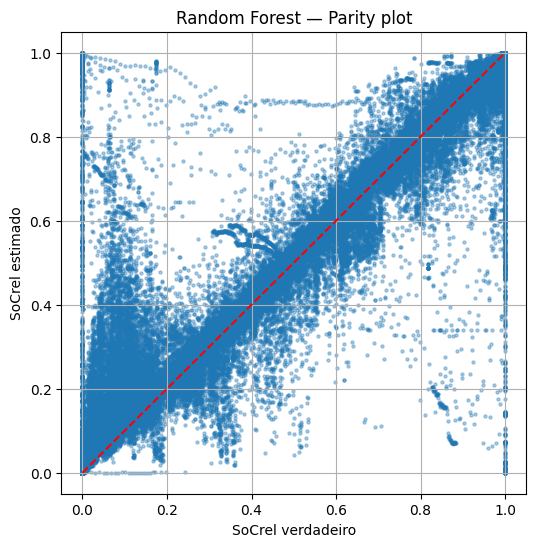

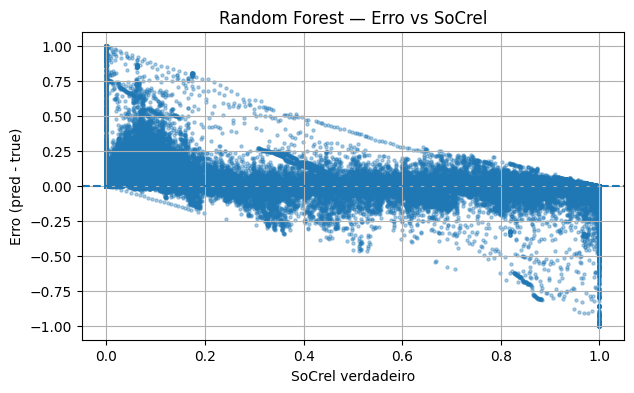

In [8]:
# ============================================================
# CÉLULA 9 (Code) — Random Forest baseline
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

print("Treinando Random Forest...")
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

m_rf = eval_regression(y_test, y_pred_rf, name="RandomForest")
plot_parity(y_test, y_pred_rf, "Random Forest — Parity plot")
plot_error_vs_soc(y_test, y_pred_rf, "Random Forest — Erro vs SoCrel")


### Análise dos Resultados — Random Forest

O modelo Random Forest apresentou desempenho sólido na estimação do SoC_rel, com MAE ≈ 0,055 e R² ≈ 0,85. Estes valores indicam elevada capacidade de generalização e boa precisão global.

Os gráficos de paridade e erro vs SoC_rel mostram boa concordância entre valores estimados e reais, sobretudo nas regiões intermédias do estado de carga.


Treinando ANN (MLPRegressor)...
Iteration 1, loss = 0.01695286
Validation score: 0.705584
Iteration 2, loss = 0.01478426
Validation score: 0.722631
Iteration 3, loss = 0.01433600
Validation score: 0.733520
Iteration 4, loss = 0.01399061
Validation score: 0.723689
Iteration 5, loss = 0.01367567
Validation score: 0.748096
Iteration 6, loss = 0.01335324
Validation score: 0.749460
Iteration 7, loss = 0.01301645
Validation score: 0.757642
Iteration 8, loss = 0.01275712
Validation score: 0.762623
Iteration 9, loss = 0.01250484
Validation score: 0.766573
Iteration 10, loss = 0.01229256
Validation score: 0.769294
Iteration 11, loss = 0.01205938
Validation score: 0.777976
Iteration 12, loss = 0.01181876
Validation score: 0.779320
Iteration 13, loss = 0.01157073
Validation score: 0.780342
Iteration 14, loss = 0.01130516
Validation score: 0.793760
Iteration 15, loss = 0.01101343
Validation score: 0.793807
Iteration 16, loss = 0.01078860
Validation score: 0.800754
Iteration 17, loss = 0.01046358
V

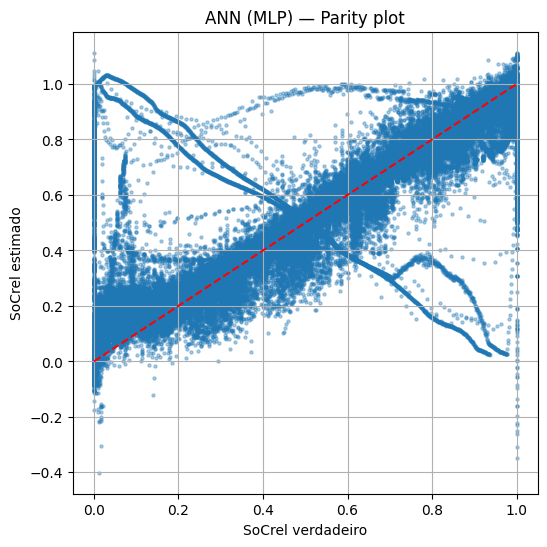

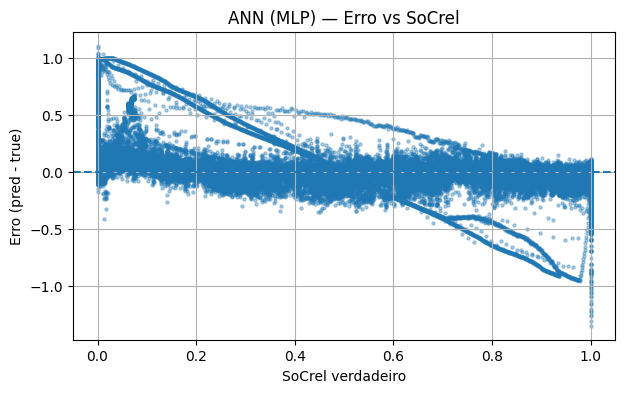

In [9]:
# ============================================================
# CÉLULA 10 (Code) — ANN baseline (MLPRegressor) + normalização
# ============================================================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ann = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=60,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=5,
        verbose=True
    ))
])

print("Treinando ANN (MLPRegressor)...")
ann.fit(X_train, y_train)

y_pred_ann = ann.predict(X_test)

m_ann = eval_regression(y_test, y_pred_ann, name="ANN_MLP")
plot_parity(y_test, y_pred_ann, "ANN (MLP) — Parity plot")
plot_error_vs_soc(y_test, y_pred_ann, "ANN (MLP) — Erro vs SoCrel")


### Análise dos Resultados — ANN (MLP)

Os gráficos evidenciam desempenho inferior da ANN (MLP) face ao Random Forest, com maior dispersão dos erros e R² mais baixo. Observa-se um **viés sistemático dependente do SoC**, visível pela tendência para **sobrestimar valores baixos de SoC** e **subestimar valores elevados**.

As trajetórias inclinadas nos gráficos indicam que o modelo aprende a tendência média global, mas não captura adequadamente a dependência temporal do SoC, resultando em erros estruturados nas regiões extremas. Apesar destas limitações, a ANN mantém valor como baseline comparativo.


In [10]:
# ============================================================
# CÉLULA 11 (Code) — Comparação RF vs ANN + guardar outputs
# ============================================================

import pandas as pd
from pathlib import Path
import joblib

results = pd.DataFrame([m_rf, m_ann])
results


,model,MAE,RMSE,R2
0,RandomForest,0.054935,0.130352,0.847118
1,ANN_MLP,0.099779,0.193098,0.664511


### Análise dos Resultados — Comparação entre Modelos

A comparação direta evidencia a superioridade do Random Forest em todas as métricas avaliadas. O modelo apresenta menor erro e maior capacidade explicativa quando comparado à ANN.

Estes resultados justificam a escolha do Random Forest como baseline principal para comparação com modelos mais leves ou especializados.


In [11]:
# ============================================================
# CÉLULA 12 — Métricas por tipo de ensaio (RF vs ANN)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1) Função para inferir tipo de ensaio a partir do file_id
# ------------------------------------------------------------
def infer_test_type(file_id: str) -> str:
    s = str(file_id)
    if "HPPC" in s:
        return "HPPC"
    if any(x in s for x in ["UDDS", "HWFET", "US06", "LA92"]):
        return "DriveCycle"
    if "Mixed" in s:
        return "Mixed"
    if any(x in s for x in ["Charge", "Dis", "Cap"]):
        return "Cycle"
    return "Other"

# ------------------------------------------------------------
# 2) Preparar DataFrame de teste (verdade + metadados)
# ------------------------------------------------------------
df_test = dfm.loc[test_mask, [col_file, target_col]].copy()
df_test = df_test.reset_index(drop=True)

df_test["test_type"] = df_test[col_file].apply(infer_test_type)

# alinhar predições (mesma ordem de X_test)
df_test["pred_rf"]  = y_pred_rf
df_test["pred_ann"] = y_pred_ann

print("✔ DataFrame de teste preparado:", df_test.shape)

# ------------------------------------------------------------
# 3) Função de métricas por grupo
# ------------------------------------------------------------
def metrics_by_group(df, pred_col, true_col, group_col):
    rows = []
    for g, sub in df.groupby(group_col):
        y_true = sub[true_col].to_numpy()
        y_pred = sub[pred_col].to_numpy()

        rows.append({
            "type": g,
            "n_samples": len(sub),
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "R2": r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan
        })
    return pd.DataFrame(rows).sort_values("n_samples", ascending=False)

# ------------------------------------------------------------
# 4) Calcular métricas por tipo (RF e ANN)
# ------------------------------------------------------------
metrics_rf_bytype  = metrics_by_group(df_test, "pred_rf",  target_col, "test_type")
metrics_ann_bytype = metrics_by_group(df_test, "pred_ann", target_col, "test_type")

# ------------------------------------------------------------
# 5) Mostrar resultados
# ------------------------------------------------------------
print("\n=== Random Forest — Métricas por tipo de ensaio ===")
display(metrics_rf_bytype)

print("\n=== ANN (MLP) — Métricas por tipo de ensaio ===")
display(metrics_ann_bytype)


✔ DataFrame de teste preparado: (99981, 5)

=== Random Forest — Métricas por tipo de ensaio ===


,type,n_samples,MAE,RMSE,R2
1,DriveCycle,49829,0.040847,0.077305,0.938300
2,Mixed,35686,0.039881,0.083034,0.929346
0,Cycle,8155,0.196333,0.348345,0.262145
3,Other,6311,0.068578,0.161919,0.879037



=== ANN (MLP) — Métricas por tipo de ensaio ===


,type,n_samples,MAE,RMSE,R2
1,DriveCycle,49829,0.056760,0.101771,0.893064
2,Mixed,35686,0.054595,0.087035,0.922373
0,Cycle,8155,0.366881,0.467807,-0.330720
3,Other,6311,0.349800,0.428151,0.154225


### Análise dos Resultados — Desempenho por Tipo de Ensaio

O Random Forest apresenta desempenho particularmente elevado em ensaios Drive Cycle e Mixed, que representam condições dinâmicas realistas. Em ensaios do tipo Cycle, observa-se degradação significativa do desempenho, refletindo menor variabilidade do SoC.

A ANN apresenta degradação mais acentuada em todos os tipos de ensaio, especialmente em Cycle, onde o R² é negativo, indicando fraca capacidade preditiva nestas condições.


# ============================================================
# CÉLULA 13 
# ============================================================
"""
## Notas finais
- O dataset é carregado de `df_prepared.pkl` (Input), garantindo reprodutibilidade e separação de fases.
- O split por `file_id` evita leakage e aproxima o cenário de teste a “novos ensaios”.
- RF e ANN/MLP constituem baselines “pesados” para comparação futura com modelos leves.
"""


In [12]:
# ============================================================
# CÉLULA FINAL — Guardar modelo(s) + features para usar no notebook de validação
# (Caminho A: aplicar modelo treinado ao CSV real do ESP32)
# ============================================================

import os, json, joblib
from datetime import datetime

OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

# --- 1) Guardar Random Forest (principal) ---
rf_path = os.path.join(OUT_DIR, "rf_socrel.joblib")
joblib.dump(rf, rf_path)

# --- 2) (Opcional) Guardar ANN/MLP ---
ann_path = os.path.join(OUT_DIR, "ann_socrel.joblib")
try:
    joblib.dump(ann, ann_path)
    saved_ann = True
except Exception as e:
    saved_ann = False
    print("⚠️ Não foi possível guardar ANN:", e)

# --- 3) Guardar lista de features (ordem é importante!) ---
feat_path = os.path.join(OUT_DIR, "feature_cols.json")
with open(feat_path, "w") as f:
    json.dump(feature_cols, f, indent=2)

# --- 4) Guardar 'schema' / metadados para o notebook de validação ---
# Isto ajuda a lembrar como converter o CSV real (ESP32) para o formato do treino.
schema = {
    "created_utc": datetime.utcnow().isoformat() + "Z",
    "target": "soc_rel",
    "feature_cols_in_order": feature_cols,
    "expected_units": {
        # no df_prepared.pkl (Dhakal), tipicamente:
        # voltage em V, current em A (negativo em descarga), temperature em °C
        "voltage": "V",
        "current": "A",
        "temperature": "°C",
        "dv_dt": "V/s",
        "di_dt": "A/s"
    },
    "notes_for_esp32_csv_mapping": {
        # sugestão prática para o Caminho A
        "voltage": "usar Vbat_V (ou Vbus_V se não houver Vbat_V)",
        "current": "I_mA / 1000.0 para A; confirmar sinal (Dhakal costuma ter descarga negativa)",
        "temperature": "T_C",
        "dv_dt": "derivada temporal de voltage por dt",
        "di_dt": "derivada temporal de current por dt"
    }
}
schema_path = os.path.join(OUT_DIR, "model_schema.json")
with open(schema_path, "w") as f:
    json.dump(schema, f, indent=2)

# --- 5) (Opcional) Guardar métricas do baseline ---
# Se existir 'results' (DataFrame com métricas RF vs ANN), guarda também
try:
    metrics_path = os.path.join(OUT_DIR, "baseline_metrics.csv")
    results.to_csv(metrics_path, index=False)
    saved_metrics = True
except Exception:
    saved_metrics = False

# --- 6) Confirmar outputs ---
print("\n✅ Outputs guardados em /kaggle/working:")
for p in [rf_path, feat_path, schema_path, ann_path, (metrics_path if saved_metrics else None)]:
    if p is None:
        continue
    print(" -", os.path.basename(p), "->", "OK" if os.path.exists(p) else "MISSING")

print("\n📌 Próximo passo no Kaggle:")
print("1) 'Save Version' do notebook baseline com 'Save output files' ativo")
print("2) No notebook de validação, adicionar este notebook como Input e carregar:")
print("   - /kaggle/input/<teu-notebook-baseline>/rf_socrel.joblib")
print("   - /kaggle/input/<teu-notebook-baseline>/feature_cols.json")
print("   - /kaggle/input/<teu-notebook-baseline>/model_schema.json")



✅ Outputs guardados em /kaggle/working:
 - rf_socrel.joblib -> OK
 - feature_cols.json -> OK
 - model_schema.json -> OK
 - ann_socrel.joblib -> OK
 - baseline_metrics.csv -> OK

📌 Próximo passo no Kaggle:
1) 'Save Version' do notebook baseline com 'Save output files' ativo
2) No notebook de validação, adicionar este notebook como Input e carregar:
   - /kaggle/input/<teu-notebook-baseline>/rf_socrel.joblib
   - /kaggle/input/<teu-notebook-baseline>/feature_cols.json
   - /kaggle/input/<teu-notebook-baseline>/model_schema.json


/tmp/ipykernel_17/2656901805.py:33: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_utc": datetime.utcnow().isoformat() + "Z",
